# 04 - Exploratory Data Analysis (Overview)
**Goal:** Answer four questions with clear charts: how are salaries distributed, how much does country matter, how does experience relate to salary within a country, and how does education relate to salary once country is controlled for.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold", "axes.titlesize": 13})

PRIMARY = "#4C72B0"
ACCENT = "#C44E52"

DATA_PATH = Path("../data/processed/clean_salaries.csv")
FIGURES_DIR = Path("../reports/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
assert DATA_PATH.exists(), f"File not found: {DATA_PATH.resolve()}"

TARGET = "ConvertedCompYearly"

# Format axis ticks as dollar amounts
usd = mticker.FuncFormatter(lambda x, _: f"${x:,.0f}")

def save_fig(fig, name):
    """Save a figure to reports/figures with a consistent resolution."""
    path = FIGURES_DIR / name
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"Saved: {path}")

df = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Loaded shape: {df.shape}")

Loaded shape: (21702, 14)


In [10]:
display(df[[TARGET, "WorkExp"]].describe().round(0))
print("\nMissing values (%):")
print(df.isna().mean().mul(100).round(1).sort_values(ascending=False).head(6))

,ConvertedCompYearly,WorkExp
count,21702.0,21477.0
mean,97395.0,14.0
std,83341.0,10.0
min,1000.0,1.0
25%,46406.0,6.0
50%,81210.0,12.0
75%,125786.0,20.0
max,1000000.0,65.0



Missing values (%):
RemoteWork                8.6
OrgSize                   8.1
LanguageHaveWorkedWith    6.9
WorkExp                   1.0
EdLevel                   0.1
ResponseId                0.0
dtype: float64


Saved: ..\reports\figures\01_salary_distribution.png


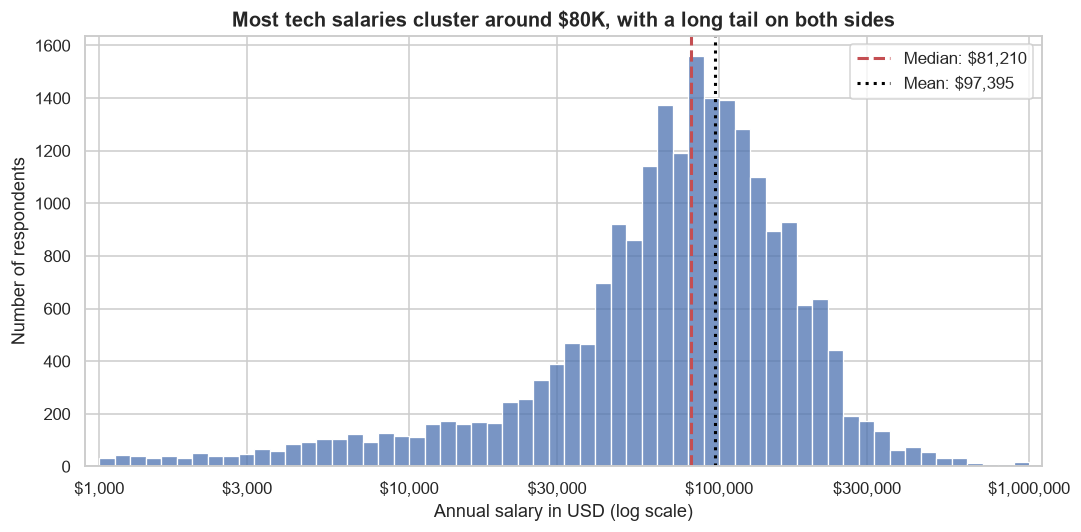

In [11]:
median = df[TARGET].median()
mean = df[TARGET].mean()

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df[TARGET], bins=60, log_scale=True, color=PRIMARY, edgecolor="white", ax=ax)

ax.axvline(median, color=ACCENT, linestyle="--", linewidth=2, label=f"Median: ${median:,.0f}")
ax.axvline(mean, color="black", linestyle=":", linewidth=2, label=f"Mean: ${mean:,.0f}")

ax.set_xticks([1e3, 3e3, 1e4, 3e4, 1e5, 3e5, 1e6])
ax.xaxis.set_major_formatter(usd)
ax.xaxis.set_minor_formatter(mticker.NullFormatter())
ax.set_xlim(900, 1.1e6)

ax.set_title("Most tech salaries cluster around $80K, with a long tail on both sides")
ax.set_xlabel("Annual salary in USD (log scale)")
ax.set_ylabel("Number of respondents")
ax.legend()
plt.tight_layout()
save_fig(fig, "01_salary_distribution.png")
plt.show()

Saved: ..\reports\figures\02_median_salary_by_country.png


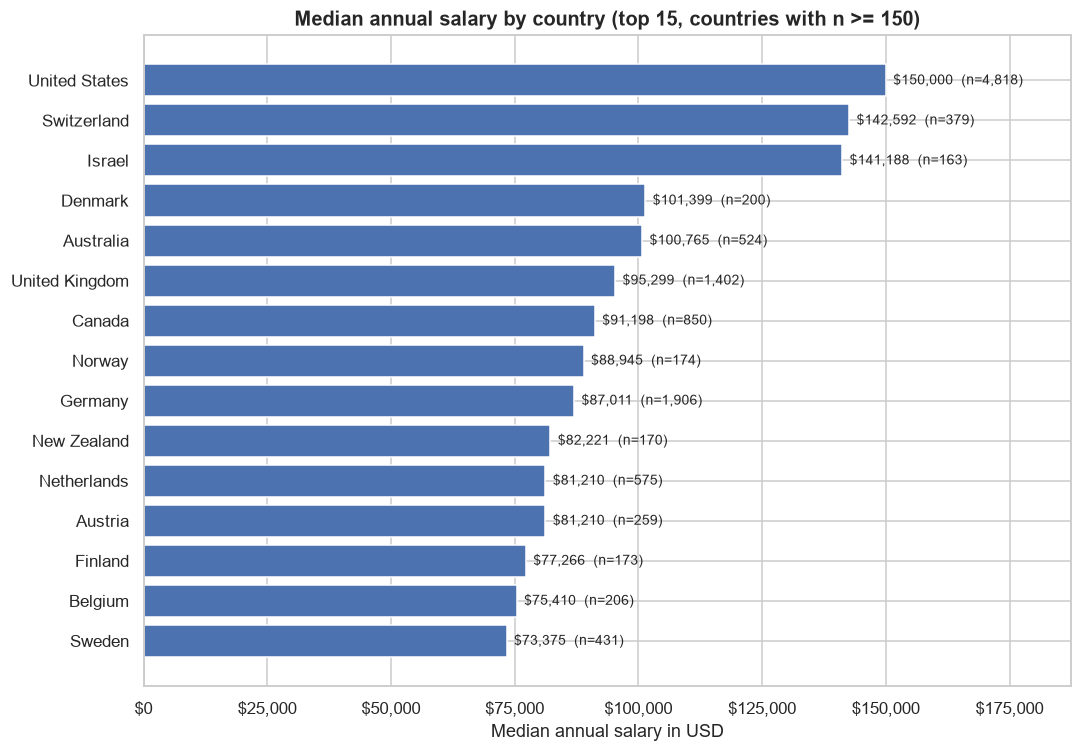

In [12]:
MIN_N = 150   # only compare countries with enough respondents

country_stats = (
    df.groupby("Country")[TARGET]
      .agg(n="count", median="median")
      .query("n >= @MIN_N")
      .sort_values("median", ascending=False)
      .head(15)
      .sort_values("median")   # ascending so the highest bar appears on top
)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(country_stats.index, country_stats["median"], color=PRIMARY)

for bar, med, n in zip(bars, country_stats["median"], country_stats["n"]):
    ax.text(bar.get_width() + 1500, bar.get_y() + bar.get_height() / 2,
            f"${med:,.0f}  (n={n:,})", va="center", fontsize=9)

ax.xaxis.set_major_formatter(usd)
ax.set_xlim(0, country_stats["median"].max() * 1.25)
ax.set_title(f"Median annual salary by country (top 15, countries with n >= {MIN_N})")
ax.set_xlabel("Median annual salary in USD")
ax.set_ylabel("")
plt.tight_layout()
save_fig(fig, "02_median_salary_by_country.png")
plt.show()

Saved: ..\reports\figures\03_salary_vs_experience.png


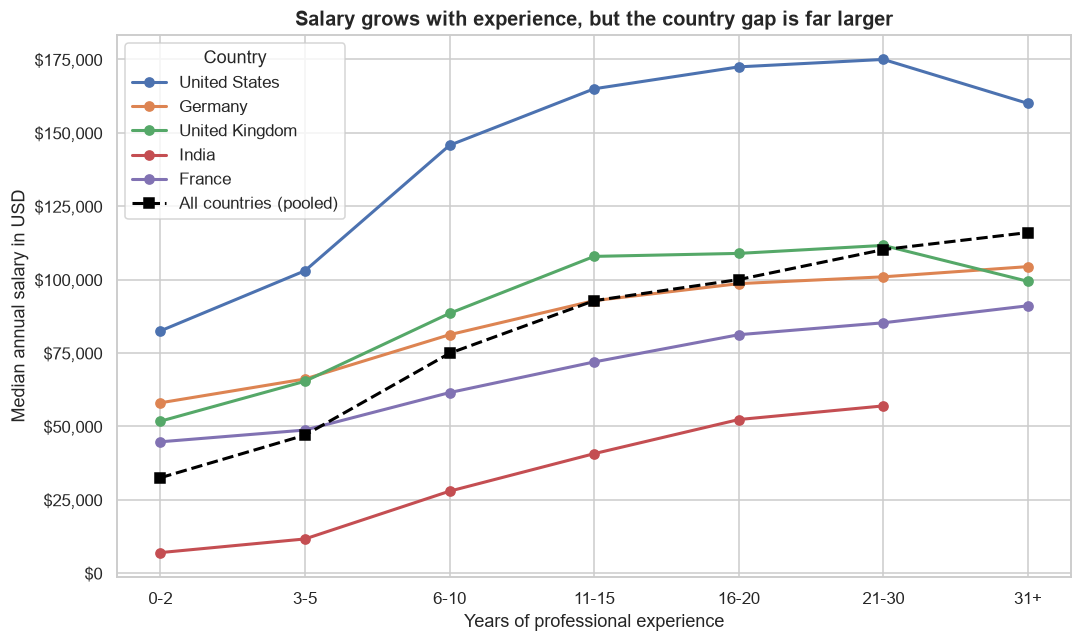

In [13]:
# Group experience into buckets; a scatter plot of 21K points would be unreadable
bins = [0, 2, 5, 10, 15, 20, 30, 70]
labels = ["0-2", "3-5", "6-10", "11-15", "16-20", "21-30", "31+"]
df["ExpBucket"] = pd.cut(df["WorkExp"], bins=bins, labels=labels, include_lowest=True)

top_countries = df["Country"].value_counts().head(5).index.tolist()
MIN_CELL = 20   # hide points built from too few respondents

by_exp = (
    df[df["Country"].isin(top_countries)]
      .groupby(["Country", "ExpBucket"], observed=True)[TARGET]
      .agg(n="count", median="median")
      .reset_index()
)
by_exp.loc[by_exp["n"] < MIN_CELL, "median"] = np.nan

pooled = df.groupby("ExpBucket", observed=True)[TARGET].median()

x_map = {lab: i for i, lab in enumerate(labels)}

fig, ax = plt.subplots(figsize=(10, 6))
for country in top_countries:
    sub = by_exp[by_exp["Country"] == country]
    ax.plot(sub["ExpBucket"].astype(str).map(x_map), sub["median"], marker="o", linewidth=2, label=country)

ax.plot(pooled.index.astype(str).map(x_map), pooled.values, color="black",
        linestyle="--", marker="s", linewidth=2, label="All countries (pooled)")

ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.yaxis.set_major_formatter(usd)
ax.set_title("Salary grows with experience, but the country gap is far larger")
ax.set_xlabel("Years of professional experience")
ax.set_ylabel("Median annual salary in USD")
ax.legend(title="Country")
plt.tight_layout()
save_fig(fig, "03_salary_vs_experience.png")
plt.show()

In [14]:
# Never group blindly: check the real values first
df["EdLevel"].value_counts(dropna=False)

EdLevel
Bachelor’s degree (B.A., B.S., B.Eng., etc.)                                          9595
Master’s degree (M.A., M.S., M.Eng., MBA, etc.)                                       6440
Some college/university study without earning a degree                                2492
Professional degree (JD, MD, Ph.D, Ed.D, etc.)                                        1253
Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)     938
Associate degree (A.A., A.S., etc.)                                                    713
Other (please specify):                                                                168
Primary/elementary school                                                               87
NaN                                                                                     16
Name: count, dtype: int64

,n,median
EdGroup,,
Secondary school,938,0.846
Some college,2492,0.957
Associate,713,0.867
Bachelor's,9595,1.000
Master's,6440,1.071
Doctorate / professional,1253,1.071


Saved: ..\reports\figures\04_salary_vs_education.png


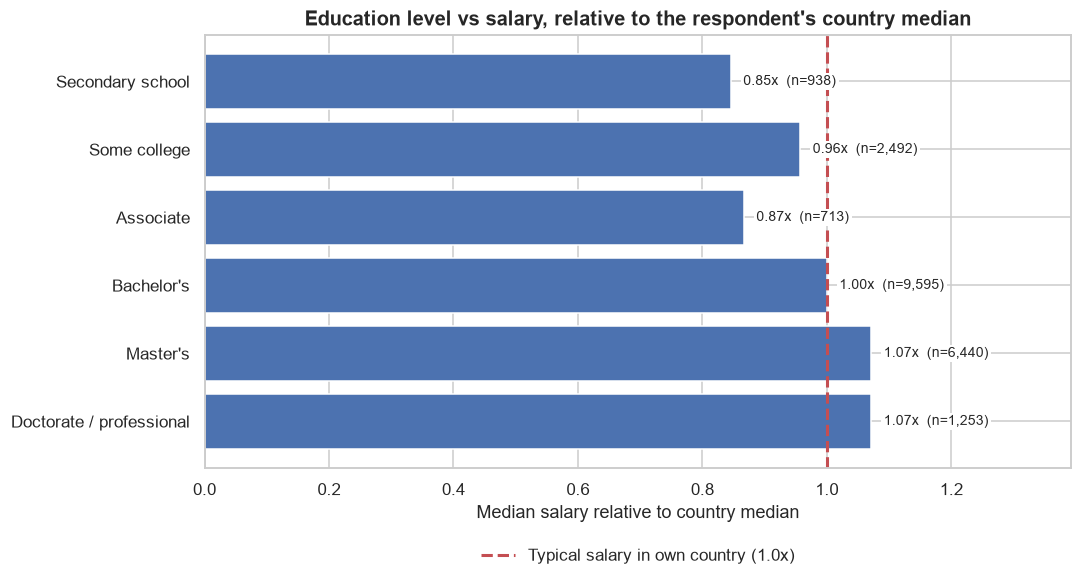

In [15]:
def simplify_education(text):
    """Map the long survey answers to a few readable groups."""
    if pd.isna(text):
        return np.nan
    t = text.lower()
    if "professional degree" in t or "ph.d" in t or "doctorate" in t:
        return "Doctorate / professional"
    if "master" in t:
        return "Master's"
    if "bachelor" in t:
        return "Bachelor's"
    if "associate" in t:
        return "Associate"
    if "some college" in t:
        return "Some college"
    if "secondary" in t:
        return "Secondary school"
    if "primary" in t:
        return "Primary school"
    return "Other"

df["EdGroup"] = df["EdLevel"].apply(simplify_education)

# Normalize: a value of 1.0 means "typical for that person's country".
# This removes the country effect so education groups can be compared fairly.
country_median = df.groupby("Country")[TARGET].transform("median")
df["RelSalary"] = df[TARGET] / country_median

ED_ORDER = ["Secondary school", "Some college", "Associate", "Bachelor's",
            "Master's", "Doctorate / professional"]

ed_stats = (
    df.groupby("EdGroup")["RelSalary"]
      .agg(n="count", median="median")
      .reindex(ED_ORDER)
      .dropna()
)
ed_stats = ed_stats[ed_stats["n"] >= 100]
display(ed_stats.round(3))

fig, ax = plt.subplots(figsize=(10, 5.5))
bars = ax.barh(ed_stats.index, ed_stats["median"], color=PRIMARY)
ax.axvline(1.0, color=ACCENT, linestyle="--", linewidth=2, label="Typical salary in own country (1.0x)")

# Value labels with a white background so the dashed line does not hide the text
for bar, med, n in zip(bars, ed_stats["median"], ed_stats["n"]):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height() / 2,
            f"{med:.2f}x  (n={n:,})", va="center", fontsize=9,
            bbox=dict(facecolor="white", edgecolor="none", pad=1.5))

ax.invert_yaxis()   # lowest education on top, highest at the bottom
ax.set_xlim(0, ed_stats["median"].max() * 1.3)
ax.set_title("Education level vs salary, relative to the respondent's country median")
ax.set_xlabel("Median salary relative to country median")
ax.set_ylabel("")

# Legend below the plot so it never covers a bar or a label
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), frameon=False)
plt.tight_layout()
save_fig(fig, "04_salary_vs_education.png")
plt.show()

In [16]:
print(f"Overall median salary : ${median:,.0f}")
print(f"Overall mean salary   : ${mean:,.0f}")

us = df.loc[df["Country"] == "United States", TARGET].median()
india = df.loc[df["Country"] == "India", TARGET].median()
print(f"US median             : ${us:,.0f}")
print(f"India median          : ${india:,.0f}")
print(f"US / India ratio      : {us / india:.1f}x")

print("\nMedian salary by experience bucket and country:")
display(by_exp.pivot(index="ExpBucket", columns="Country", values="median").round(0))

Overall median salary : $81,210
Overall mean salary   : $97,395
US median             : $150,000
India median          : $19,180
US / India ratio      : 7.8x

Median salary by experience bucket and country:


Country,France,Germany,India,United Kingdom,United States
ExpBucket,,,,,
0-2,44724.0,58007.0,6974.0,51734.0,82500.0
3-5,48726.0,66128.0,11624.0,65348.0,103000.0
6-10,61488.0,81210.0,27898.0,88492.0,145750.0
11-15,71929.0,92812.0,40684.0,107892.0,165000.0
16-20,81210.0,98612.0,52308.0,108913.0,172465.0
21-30,85271.0,100933.0,56958.0,111636.0,175000.0
31+,91072.0,104413.0,NaN,99383.0,160000.0


In [17]:
# Check the "round number" hypothesis: is EUR 70,000 a very common answer?
eur = df[df["CurrencyCode"] == "EUR"]
top_values = eur["CompTotal"].value_counts().head(8)
print("Most common reported salaries in EUR:")
print(top_values)

share = (eur["CompTotal"] == 70000).mean()
print(f"\nShare of EUR respondents reporting exactly 70,000: {share:.1%}")

Most common reported salaries in EUR:
CompTotal
60000.0     325
80000.0     266
70000.0     262
50000.0     261
100000.0    255
40000.0     194
65000.0     182
90000.0     177
Name: count, dtype: int64

Share of EUR respondents reporting exactly 70,000: 4.1%


In [18]:
# Who sits exactly on the overall median value?
median_value = round(df[TARGET].median())
exact = df[TARGET].round(0) == median_value

print(f"Respondents with salary = ${median_value:,}: {exact.sum():,} ({exact.mean():.1%} of the data)")
print("\nBy currency:")
print(df.loc[exact, "CurrencyCode"].value_counts().head(5))
print("\nBy reported amount:")
print(df.loc[exact, "CompTotal"].value_counts().head(5))

Respondents with salary = $81,210: 262 (1.2% of the data)

By currency:
CurrencyCode
EUR    262
Name: count, dtype: int64

By reported amount:
CompTotal
70000.0    262
Name: count, dtype: int64
